# Pump Sound Classification Pipeline

This notebook trains and compares several models for **normal vs. abnormal pump sound classification**.

## What is inside
- Load audio files
- Extract log-mel spectrogram features
- Train a CNN baseline
- Extract features with **AST** and **Wav2Vec2**
- Train anomaly-detection models:
  - One-Class SVM
  - Isolation Forest
  - Teacher-Student
- Compare all models in one results table

## Notes
- The AST and Wav2Vec2 sections download pretrained models, so they may run slowly in Colab.
- Update `DATA_DIR` below to match your dataset location.


## 1) Setup and data path

Choose the option that matches where your data is stored.

**Expected folder structure**
```text
data/
├── normal/
│   └── ... .wav files
└── abnormal/
    └── ... .wav files
```


In [ ]:
# Optional: Colab Google Drive mount
# Run this only if your dataset is stored in Google Drive.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import glob

# TODO: change this path if needed
DATA_DIR = "/content/drive/MyDrive/pump_sound_project/data"

files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

print("Data directory:", DATA_DIR)
print("Number of audio files found:", len(files))
print("Example files:", files[:5])


Data directory: /content/drive/MyDrive/pump_sound_project/data
Number of audio files found: 519
Example files: ['/content/drive/MyDrive/pump_sound_project/data/abnormal/00000000.wav', '/content/drive/MyDrive/pump_sound_project/data/abnormal/00000001.wav', '/content/drive/MyDrive/pump_sound_project/data/abnormal/00000003.wav', '/content/drive/MyDrive/pump_sound_project/data/abnormal/00000002.wav', '/content/drive/MyDrive/pump_sound_project/data/abnormal/00000004.wav']


## 2) Install and import dependencies

This notebook uses:
- `librosa` for audio loading and spectrograms
- `tensorflow` for the CNN baseline
- `transformers` + `torch` for pretrained audio models
- `scikit-learn` for classical ML and anomaly detection


In [ ]:
!pip -q install librosa transformers torch torchaudio scikit-learn


In [ ]:
import os
import time
import pickle
import glob
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    confusion_matrix,
)

from transformers import (
    AutoFeatureExtractor,
    ASTForAudioClassification,
    Wav2Vec2Processor,
    Wav2Vec2Model,
)

import torch

# Shared constants keep magic numbers in one place.
RANDOM_STATE = 42
SAMPLE_RATE = 16000
CLIP_SECONDS = 5
N_MELS = 64
TF_BATCH_SIZE = 32
EMBEDDING_BATCH_SIZE = 4
CNN_EPOCHS = 5

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## 3) Helper functions and shared constants


In [ ]:
def load_waveform(path, sr=SAMPLE_RATE, seconds=CLIP_SECONDS):
    """Load one audio file, then pad or trim it to a fixed length."""
    audio, _ = librosa.load(path, sr=sr)
    target_len = sr * seconds

    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    return audio.astype(np.float32)


def wav_to_logmel(path, sr=SAMPLE_RATE, n_mels=N_MELS, seconds=CLIP_SECONDS):
    """Convert one audio file into a log-mel spectrogram."""
    audio = load_waveform(path, sr=sr, seconds=seconds)
    spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_mels)
    log_spec = librosa.power_to_db(spec, ref=np.max).astype(np.float32)
    return log_spec[..., None]  # shape: (mels, time, 1)


def make_tf_dataset(paths, labels, batch_size=TF_BATCH_SIZE):
    """Build a TensorFlow dataset from file paths and labels."""
    def generator():
        for path, label in zip(paths, labels):
            yield wav_to_logmel(path), np.int32(label)

    sample = wav_to_logmel(paths[0])
    signature = (
        tf.TensorSpec(shape=sample.shape, dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32),
    )

    dataset = tf.data.Dataset.from_generator(generator, output_signature=signature)
    return dataset.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)


def safe_auc(y_true, y_score):
    """Return AUC when possible, otherwise NaN."""
    try:
        return roc_auc_score(y_true, y_score)
    except Exception:
        return np.nan


def model_size_mb(model_obj, tmp_path="/tmp/_model_size.pkl"):
    """Estimate model size in MB for both Keras and sklearn-style models."""
    try:
        if isinstance(model_obj, tf.keras.Model):
            weights_path = tmp_path + ".weights.h5"
            model_obj.save_weights(weights_path)
            size_mb = os.path.getsize(weights_path) / (1024 ** 2)
            os.remove(weights_path)
            return size_mb

        with open(tmp_path, "wb") as file_obj:
            pickle.dump(model_obj, file_obj)

        size_mb = os.path.getsize(tmp_path) / (1024 ** 2)
        os.remove(tmp_path)
        return size_mb
    except Exception:
        return np.nan


def summarize_scores(y_true, y_pred, y_score, train_time_s, model_obj):
    """Collect the main metrics for one model in one place."""
    return {
        "AUC": safe_auc(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Train Time (s)": train_time_s,
        "Model Size (MB)": model_size_mb(model_obj),
    }


def build_cnn_model(input_shape):
    """Create the baseline CNN used on log-mel spectrograms."""
    cnn_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(16, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

    cnn_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return cnn_model


def fit_linear_probe(train_features, train_labels, val_features):
    """Train Logistic Regression on extracted embeddings and return predictions."""
    classifier = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    classifier.fit(train_features, train_labels)

    val_probabilities = classifier.predict_proba(val_features)[:, 1]
    val_predictions = (val_probabilities >= 0.5).astype(int)
    return classifier, val_probabilities, val_predictions


## 4) Load file paths and create train/validation split


In [ ]:
normal_files = glob.glob(os.path.join(DATA_DIR, "normal", "**", "*.wav"), recursive=True)
abnormal_files = glob.glob(os.path.join(DATA_DIR, "abnormal", "**", "*.wav"), recursive=True)

file_paths = normal_files + abnormal_files
labels = np.array([0] * len(normal_files) + [1] * len(abnormal_files))

print("Normal files:", len(normal_files))
print("Abnormal files:", len(abnormal_files))
print("Total files:", len(file_paths))

trainX, valX, trainy, valy = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=labels,
)

train_ds = make_tf_dataset(trainX, trainy, batch_size=TF_BATCH_SIZE)
val_ds = make_tf_dataset(valX, valy, batch_size=TF_BATCH_SIZE)

print("Train samples:", len(trainX))
print("Validation samples:", len(valX))


Normal files: 381
Abnormal files: 138
Total files: 519
Train samples: 415
Validation samples: 104


## 5) Baseline model: CNN on log-mel spectrograms


In [ ]:
cnn_start = time.time()

input_shape = wav_to_logmel(trainX[0]).shape
cnn_model = build_cnn_model(input_shape)

history = cnn_model.fit(train_ds, validation_data=val_ds, epochs=CNN_EPOCHS)
cnn_train_time = time.time() - cnn_start


Epoch 1/5
     13/Unknown 125s 176ms/step - accuracy: 0.5370 - loss: 16.4124

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


13/13 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5807 - loss: 10.4991 - val_accuracy: 0.7500 - val_loss: 0.5251
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 525ms/step - accuracy: 0.7663 - loss: 0.4965 - val_accuracy: 0.8846 - val_loss: 0.4098
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 759ms/step - accuracy: 0.8723 - loss: 0.3044 - val_accuracy: 0.8750 - val_loss: 0.3443
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 55s 731ms/step - accuracy: 0.8988 - loss: 0.2485 - val_accuracy: 0.8846 - val_loss: 0.2657
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 23s 479ms/step - accuracy: 0.9229 - loss: 0.1890 - val_accuracy: 0.9231 - val_loss: 0.2172


## 6) AST features + Logistic Regression

AST = **Audio Spectrogram Transformer**.



In [ ]:
def extract_ast_features(paths, batch_size=EMBEDDING_BATCH_SIZE):
    feature_extractor = AutoFeatureExtractor.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593"
    )
    ast_model = ASTForAudioClassification.from_pretrained(
        "MIT/ast-finetuned-audioset-10-10-0.4593"
    ).to(device)
    ast_model.eval()

    features = []

    for start_idx in range(0, len(paths), batch_size):
        batch_paths = paths[start_idx:start_idx + batch_size]
        batch_audio = [load_waveform(path) for path in batch_paths]

        inputs = feature_extractor(
            batch_audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
        )
        inputs = {key: value.to(device) for key, value in inputs.items()}

        with torch.no_grad():
            outputs = ast_model(**inputs, output_hidden_states=True)
            hidden_states = outputs.hidden_states[-1]
            batch_features = hidden_states.mean(dim=1).detach().cpu().numpy()

        features.append(batch_features)

    return np.vstack(features)


ast_start = time.time()
ast_train_features = extract_ast_features(trainX)
ast_val_features = extract_ast_features(valX)

ast_clf, ast_val_proba, ast_val_pred = fit_linear_probe(
    ast_train_features,
    trainy,
    ast_val_features,
)

ast_train_time = time.time() - ast_start

print("AST feature shapes:", ast_train_features.shape, ast_val_features.shape)
print("AST validation accuracy:", accuracy_score(valy, ast_val_pred))


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

## 7) Wav2Vec2 features + Logistic Regression

Wav2Vec2 learns useful audio representations directly from raw waveform data.


In [ ]:
def extract_wav2vec_features(paths, batch_size=EMBEDDING_BATCH_SIZE):
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
    wav2vec_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
    wav2vec_model.eval()

    features = []

    for start_idx in range(0, len(paths), batch_size):
        batch_paths = paths[start_idx:start_idx + batch_size]
        batch_audio = [load_waveform(path) for path in batch_paths]

        inputs = processor(
            batch_audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            padding=True,
        )

        input_values = inputs.input_values.to(device)
        attention_mask = (
            inputs.attention_mask.to(device)
            if hasattr(inputs, "attention_mask")
            else None
        )

        with torch.no_grad():
            outputs = wav2vec_model(
                input_values=input_values,
                attention_mask=attention_mask,
            )
            hidden_states = outputs.last_hidden_state
            batch_features = hidden_states.mean(dim=1).detach().cpu().numpy()

        features.append(batch_features)

    return np.vstack(features)


wav2vec_start = time.time()
wav2vec_train_features = extract_wav2vec_features(trainX)
wav2vec_val_features = extract_wav2vec_features(valX)

wav2vec_clf, wav2vec_val_proba, wav2vec_val_pred = fit_linear_probe(
    wav2vec_train_features,
    trainy,
    wav2vec_val_features,
)

wav2vec_train_time = time.time() - wav2vec_start

print("Wav2Vec2 feature shapes:", wav2vec_train_features.shape, wav2vec_val_features.shape)
print("Wav2Vec2 validation accuracy:", accuracy_score(valy, wav2vec_val_pred))


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2 feature shapes: (415, 768) (104, 768)
Wav2Vec2 validation accuracy: 0.8942307692307693


## 8) Anomaly detection models

These models are trained only on **normal** training samples.


In [ ]:
normal_train_mask = (trainy == 0)


In [ ]:
# One-Class SVM
svm_start = time.time()

ocsvm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
ocsvm.fit(wav2vec_train_features[normal_train_mask])

ocsvm_raw_pred = ocsvm.predict(wav2vec_val_features)
ocsvm_val_pred = (ocsvm_raw_pred == -1).astype(int)
ocsvm_val_score = -ocsvm.decision_function(wav2vec_val_features).ravel()
ocsvm_train_time = time.time() - svm_start

print("One-Class SVM validation accuracy:", accuracy_score(valy, ocsvm_val_pred))


One-Class SVM validation accuracy: 0.7019230769230769


In [ ]:
# Isolation Forest
if_start = time.time()

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, float(np.mean(trainy))),
    random_state=42,
)
iso_forest.fit(wav2vec_train_features[normal_train_mask])

iso_raw_pred = iso_forest.predict(wav2vec_val_features)
iso_val_pred = (iso_raw_pred == -1).astype(int)
iso_val_score = -iso_forest.score_samples(wav2vec_val_features)
iso_train_time = time.time() - if_start

print("Isolation Forest validation accuracy:", accuracy_score(valy, iso_val_pred))


Isolation Forest validation accuracy: 0.6346153846153846


In [ ]:
# Teacher-Student
teacher_student_start = time.time()

train_logmels = np.stack([wav_to_logmel(path) for path in trainX]).astype(np.float32)
val_logmels = np.stack([wav_to_logmel(path) for path in valX]).astype(np.float32)

train_flat = train_logmels.reshape(len(train_logmels), -1)
val_flat = val_logmels.reshape(len(val_logmels), -1)
normal_train_flat = train_flat[normal_train_mask]

teacher = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(normal_train_flat.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
], name="teacher")
teacher.trainable = False

student = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(normal_train_flat.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128),
], name="student")

student.compile(optimizer="adam", loss="mse")

teacher_targets = teacher.predict(normal_train_flat, verbose=0)
student.fit(normal_train_flat, teacher_targets, epochs=CNN_EPOCHS, batch_size=TF_BATCH_SIZE, verbose=1)

val_teacher = teacher.predict(val_flat, verbose=0)
val_student = student.predict(val_flat, verbose=0)
ts_val_score = np.mean((val_teacher - val_student) ** 2, axis=1)

train_teacher = teacher.predict(normal_train_flat, verbose=0)
train_student = student.predict(normal_train_flat, verbose=0)
ts_train_score = np.mean((train_teacher - train_student) ** 2, axis=1)

ts_threshold = np.percentile(ts_train_score, 95)
ts_val_pred = (ts_val_score > ts_threshold).astype(int)
teacher_student_train_time = time.time() - teacher_student_start

print("Teacher-Student validation accuracy:", accuracy_score(valy, ts_val_pred))


Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 3638.4050
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 468.8465
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 459.7537
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 448.6032
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 433.5676
Teacher-Student validation accuracy: 0.8365384615384616


## 9) Model comparison

This table is the main summary output.


In [ ]:
results = {}

# CNN
cnn_val_proba = cnn_model.predict(val_ds, verbose=0).ravel()
cnn_val_pred = (cnn_val_proba >= 0.5).astype(int)

results["CNN (log-mel)"] = summarize_scores(
    valy,
    cnn_val_pred,
    cnn_val_proba,
    train_time_s=cnn_train_time,
    model_obj=cnn_model,
)

#results["AST + LogisticRegression"] = summarize_scores(
 #   valy,
#    ast_val_pred,
 #   ast_val_proba,
 #   train_time_s=ast_train_time,
 #   model_obj=ast_clf,
#)

results["Wav2Vec2 + LogisticRegression"] = summarize_scores(
    valy,
    wav2vec_val_pred,
    wav2vec_val_proba,
    train_time_s=wav2vec_train_time,
    model_obj=wav2vec_clf,
)

results["One-Class SVM"] = summarize_scores(
    valy,
    ocsvm_val_pred,
    ocsvm_val_score,
    train_time_s=ocsvm_train_time,
    model_obj=ocsvm,
)

results["Isolation Forest"] = summarize_scores(
    valy,
    iso_val_pred,
    iso_val_score,
    train_time_s=iso_train_time,
    model_obj=iso_forest,
)

results["Teacher-Student"] = summarize_scores(
    valy,
    ts_val_pred,
    ts_val_score,
    train_time_s=teacher_student_train_time,
    model_obj=student,
)

results_df = pd.DataFrame(results).T.round(4)
results_df.sort_values(by="AUC", ascending=False)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


,AUC,Accuracy,F1,Sensitivity,Train Time (s),Model Size (MB)
Wav2Vec2 + LogisticRegression,0.8816,0.8942,0.7755,0.6786,875.3805,0.0065
Teacher-Student,0.8651,0.8365,0.6383,0.5357,26.0958,29.8361
One-Class SVM,0.6504,0.7019,0.2439,0.1786,0.0251,0.2124
Isolation Forest,0.6297,0.6346,0.2400,0.2143,0.4950,3.3868
CNN (log-mel),0.4953,0.6346,0.2083,0.1786,308.4257,12.2274


## 10) CNN evaluation and visualizations


In [ ]:
cnn_model.evaluate(val_ds, verbose=1)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9231 - loss: 0.2172


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.2171512246131897, 0.9230769276618958]

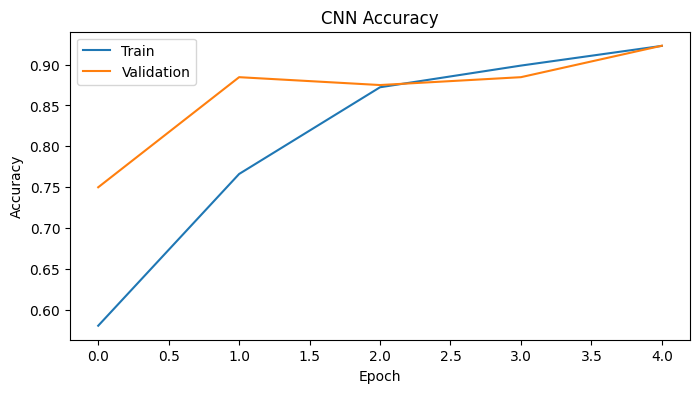

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


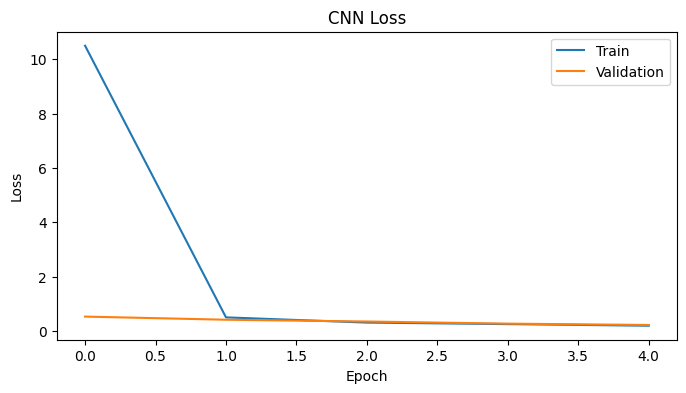

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


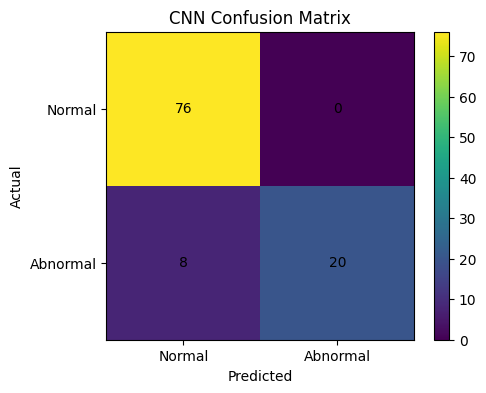

In [ ]:
y_true = []
y_pred = []

for batch_x, batch_y in val_ds:
    preds = cnn_model.predict(batch_x, verbose=0)
    preds = (preds > 0.5).astype(int)

    y_true.extend(batch_y.numpy())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("CNN Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Normal", "Abnormal"])
plt.yticks([0, 1], ["Normal", "Abnormal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


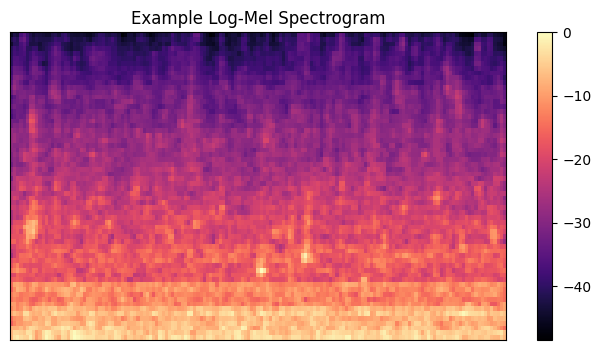

In [ ]:
spec = wav_to_logmel(trainX[0])[:, :, 0]

plt.figure(figsize=(8, 4))
librosa.display.specshow(spec)
plt.title("Example Log-Mel Spectrogram")
plt.colorbar()
plt.show()
